In [104]:
import os
import shutil
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import array_to_img, img_to_array, load_img
from keras.preprocessing.image import ImageDataGenerator

In [105]:
np.__version__

'1.26.0'

In [106]:
import mlflow
import mlflow.keras

Start MLFlow-Server with

# C:\Tools\WPy64-C2C-3940\WPy64-3940\scripts>mlflow server --host 127.0.0.2 --port 8080

python -m venv .venv
.venv\scripts\activate
- deactivate

pip install numpy==1.26

pip install opencv-python

pip install tensorflow==2.8

pip install protobuf==3.20 # evtl. unnötig

pip install mlflow

mlflow server --host 127.0.0.2 --port 8080

PlugIn: Window Colors

python_requirements.txt

.gitignore
- .vscode
- .venv

In [107]:
mlflow.set_tracking_uri(uri="http://127.0.0.2:8080")
mlflow.set_experiment("Camp2Code - Raspi Car")
mlflow.keras.autolog()

In [108]:
# Bildgrößen und Pfad definieren
IMAGE_SIZE = (128, 128)
IMAGE_DIRECTORY = "use_these_images"

In [144]:
# Funktion zum Einlesen der Bilder und Labels
def load_images_from_directory(directory):
    images = []
    labels = []

    for filename in os.listdir(directory):
        if filename.endswith('.jpg'):
          # label = filename.split('_')[1].split(".")[0]
          label = filename.split("_")[4].split(".")[0]
        else:
          continue

        label = float(label)

        img = cv2.imread(os.path.join(directory, filename))

        img_crop = img[150:350,:,:]
        # img_blur = cv2.blur(img_crop,(5, 5))
        # img_hsv = cv2.cvtColor(img_blur, cv2.COLOR_BGR2HSV)
        # lower_blue = np.array([94, 40, 100])
        # upper_blue = np.array([132, 255, 255])
        # mask = cv2.inRange(img_hsv, lower_blue, upper_blue)
        # edges = cv2.Canny(mask, 50, 150, apertureSize=3)

        
        # # ERSTMAL wieder zurück in BGR-Raum
        # img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

        img = cv2.resize(img_crop, IMAGE_SIZE)
        img = img / 255.0

        images.append(img)
        labels.append(label)

        # hier einmal die Spiegelung der bestehenden Bilder
        # images.append(img[:,::-1])
        images.append(img[:,::-1,:])
        labels.append(180-label)
      
    return np.array(images), np.array(labels)


# Teil der Aufgabe - nicht löschen
def plot_images_from_array(x_train, labels, pred, grid=(15,15),figsize=(16,16)):
    """
    Plottet die ersten Images aus x_train
    labels: Array der labels
    """
    
    W_grid=grid[0]
    L_grid=grid[1]
    fig, axes = plt.subplots(L_grid, W_grid, figsize = figsize)
    axes = axes.ravel()      #ähnlich wie "flatten": https://numpy.org/doc/stable/reference/generated/numpy.ravel.html
    for i in np.arange(0, W_grid * L_grid): 
        index=i
        if index<len(x_train):
            axes[i].imshow(x_train[index][:,:,::-1])
            axes[i].set_title(str(int(labels[index])) + " -> " + str(int(pred[index])), fontsize = 16)
            axes[i].axis('off')
    plt.subplots_adjust(hspace=0.3)
    
def plot_train_history(history):
  plt.plot(history.history['loss'], color='blue')
  plt.plot(history.history['val_loss'], color='red')
  plt.legend(["training loss", "validation loss"])

In [145]:
# Bilder und Labels laden
images, labels = load_images_from_directory(IMAGE_DIRECTORY)

print(labels)
print(labels.shape)
print(images.shape)

[ 58. 122.  50. ... 130.  45. 135.]
(2400,)
(2400, 128, 128, 3)


In [146]:
def show_prediction(image, model):
    plt.imshow(image[:,:,::-1])
    val = model.predict(image)
    print(f"Predicted as {val}°")

In [147]:
# Durchschnitt der Labelwerte
np.mean(labels)

90.0

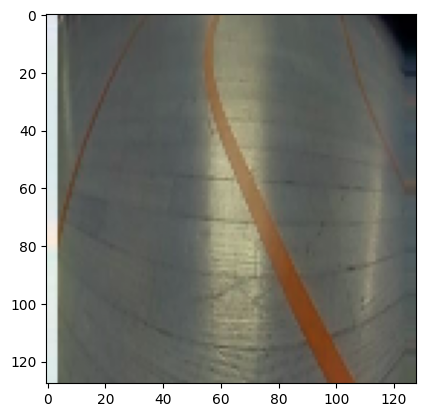

In [148]:
# plt.imshow(images[0][:,:,::-1])
plt.imshow(images[0])

In [12]:
model = Sequential([
    Input(shape=(images[0].shape)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1)
])

In [96]:
model = Sequential([
    Input(shape=(images[0].shape)),
    Conv2D(32, (3, 3), activation='relu'),
    Conv2D(48, (3, 3), activation='relu'),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1)
])

In [149]:
# nervous-rat-924
model = Sequential([
    Input(shape=(images[0].shape)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1)
])
    

In [46]:
# Modell aus Agenda_Projektphase2.pdf 

# Keras Sequntial API
model = tf.keras.Sequential(name='BeispielModell')
# Convolution Layers
# elu: Expenential Linear Unit, similar to leaky Relu
model.add(Conv2D(24, (5, 5), strides=(2, 2), input_shape=(images[0].shape), activation='relu'))
model.add(Conv2D(36, (5, 5), strides=(2, 2), activation='relu'))
model.add(Conv2D(48, (5, 5), strides=(2, 2), activation='relu'))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(Dropout(0.2)) # more robustness
model.add(Conv2D(64, (3, 3), activation='relu'))
# Fully Connected Layers
model.add(Flatten())
model.add(Dropout(0.2)) # more robustness
model.add(Dense(100, activation='relu'))
model.add(Dense(50, activation='relu'))
model.add(Dense(10, activation='relu'))
# Output Layer: turning angle
model.add(Dense(1))

In [150]:
 # Modell für Regression kompilieren
# model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
model.compile(optimizer=Adam(learning_rate = 0.001), loss='mean_squared_error', metrics=['mae'])

In [151]:
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_27 (Conv2D)          (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 63, 63, 32)       0         
 2D)                                                             
                                                                 
 conv2d_28 (Conv2D)          (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                             
                                                                 
 conv2d_29 (Conv2D)          (None, 28, 28, 128)       73856     
                                                                 
 flatten_7 (Flatten)         (None, 100352)           

In [152]:
from sklearn.model_selection import train_test_split

In [153]:
# Empfehlug test-train_test-Split
images_train, images_test, labels_train, labels_test = train_test_split(images, labels, test_size=0.2, random_state=42)
print(f"images_train = {images_train.shape}")
print(f"images_test = {images_test.shape}")
print(f"labels_train = {labels_train.shape}")
print(f"labels_test = {labels_test.shape}")


images_train = (1920, 128, 128, 3)
images_test = (480, 128, 128, 3)
labels_train = (1920,)
labels_test = (480,)


In [154]:
cp_cb = tf.keras.callbacks.ModelCheckpoint('cp_model.keras', save_best_only=True, monitor='val_loss', mode="min")
es_cb = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)
rp_cb= tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5) 

In [155]:
history = model.fit(
    images_train, 
    labels_train, 
    epochs=50, 
    validation_data=(images_test, labels_test), 
    callbacks=[cp_cb, es_cb, rp_cb], 
    batch_size=64)

2025/03/26 13:44:52 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '086c3f58728d441fa45d120aa13dd2c1', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current tensorflow workflow


Epoch 1/50
30/30 [==============================] - 14s 468ms/step - loss: 1845.9364 - mae: 34.6250 - val_loss: 1009.0445 - val_mae: 27.4750 - lr: 0.0010
Epoch 2/50
30/30 [==============================] - 14s 462ms/step - loss: 857.1257 - mae: 24.2875 - val_loss: 437.8188 - val_mae: 16.6606 - lr: 0.0010
Epoch 3/50
30/30 [==============================] - 14s 468ms/step - loss: 608.7758 - mae: 19.6208 - val_loss: 345.8868 - val_mae: 14.9198 - lr: 0.0010
Epoch 4/50
30/30 [==============================] - 14s 458ms/step - loss: 375.5049 - mae: 15.3943 - val_loss: 586.5167 - val_mae: 19.3843 - lr: 0.0010
Epoch 5/50
30/30 [==============================] - 15s 488ms/step - loss: 314.9843 - mae: 14.0189 - val_loss: 312.7638 - val_mae: 14.0004 - lr: 0.0010
Epoch 6/50
30/30 [==============================] - 15s 499ms/step - loss: 320.1790 - mae: 14.2739 - val_loss: 239.6277 - val_mae: 12.2414 - lr: 0.0010
Epoch 7/50
30/30 [==============================] - 15s 489ms/step - loss: 246.2204 - 

In [125]:
y_pred = model.predict(images)
# val = model.predict(images[100])
# show_prediction(images[1], model)

In [126]:
y_pred[100]

array([125.77532], dtype=float32)

C:\Users\VWN7QRY\AppData\Local\Temp\ipykernel_24440\3443600049.py:58: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  axes[i].set_title(str(int(labels[index])) + " -> " + str(int(pred[index])), fontsize = 16)


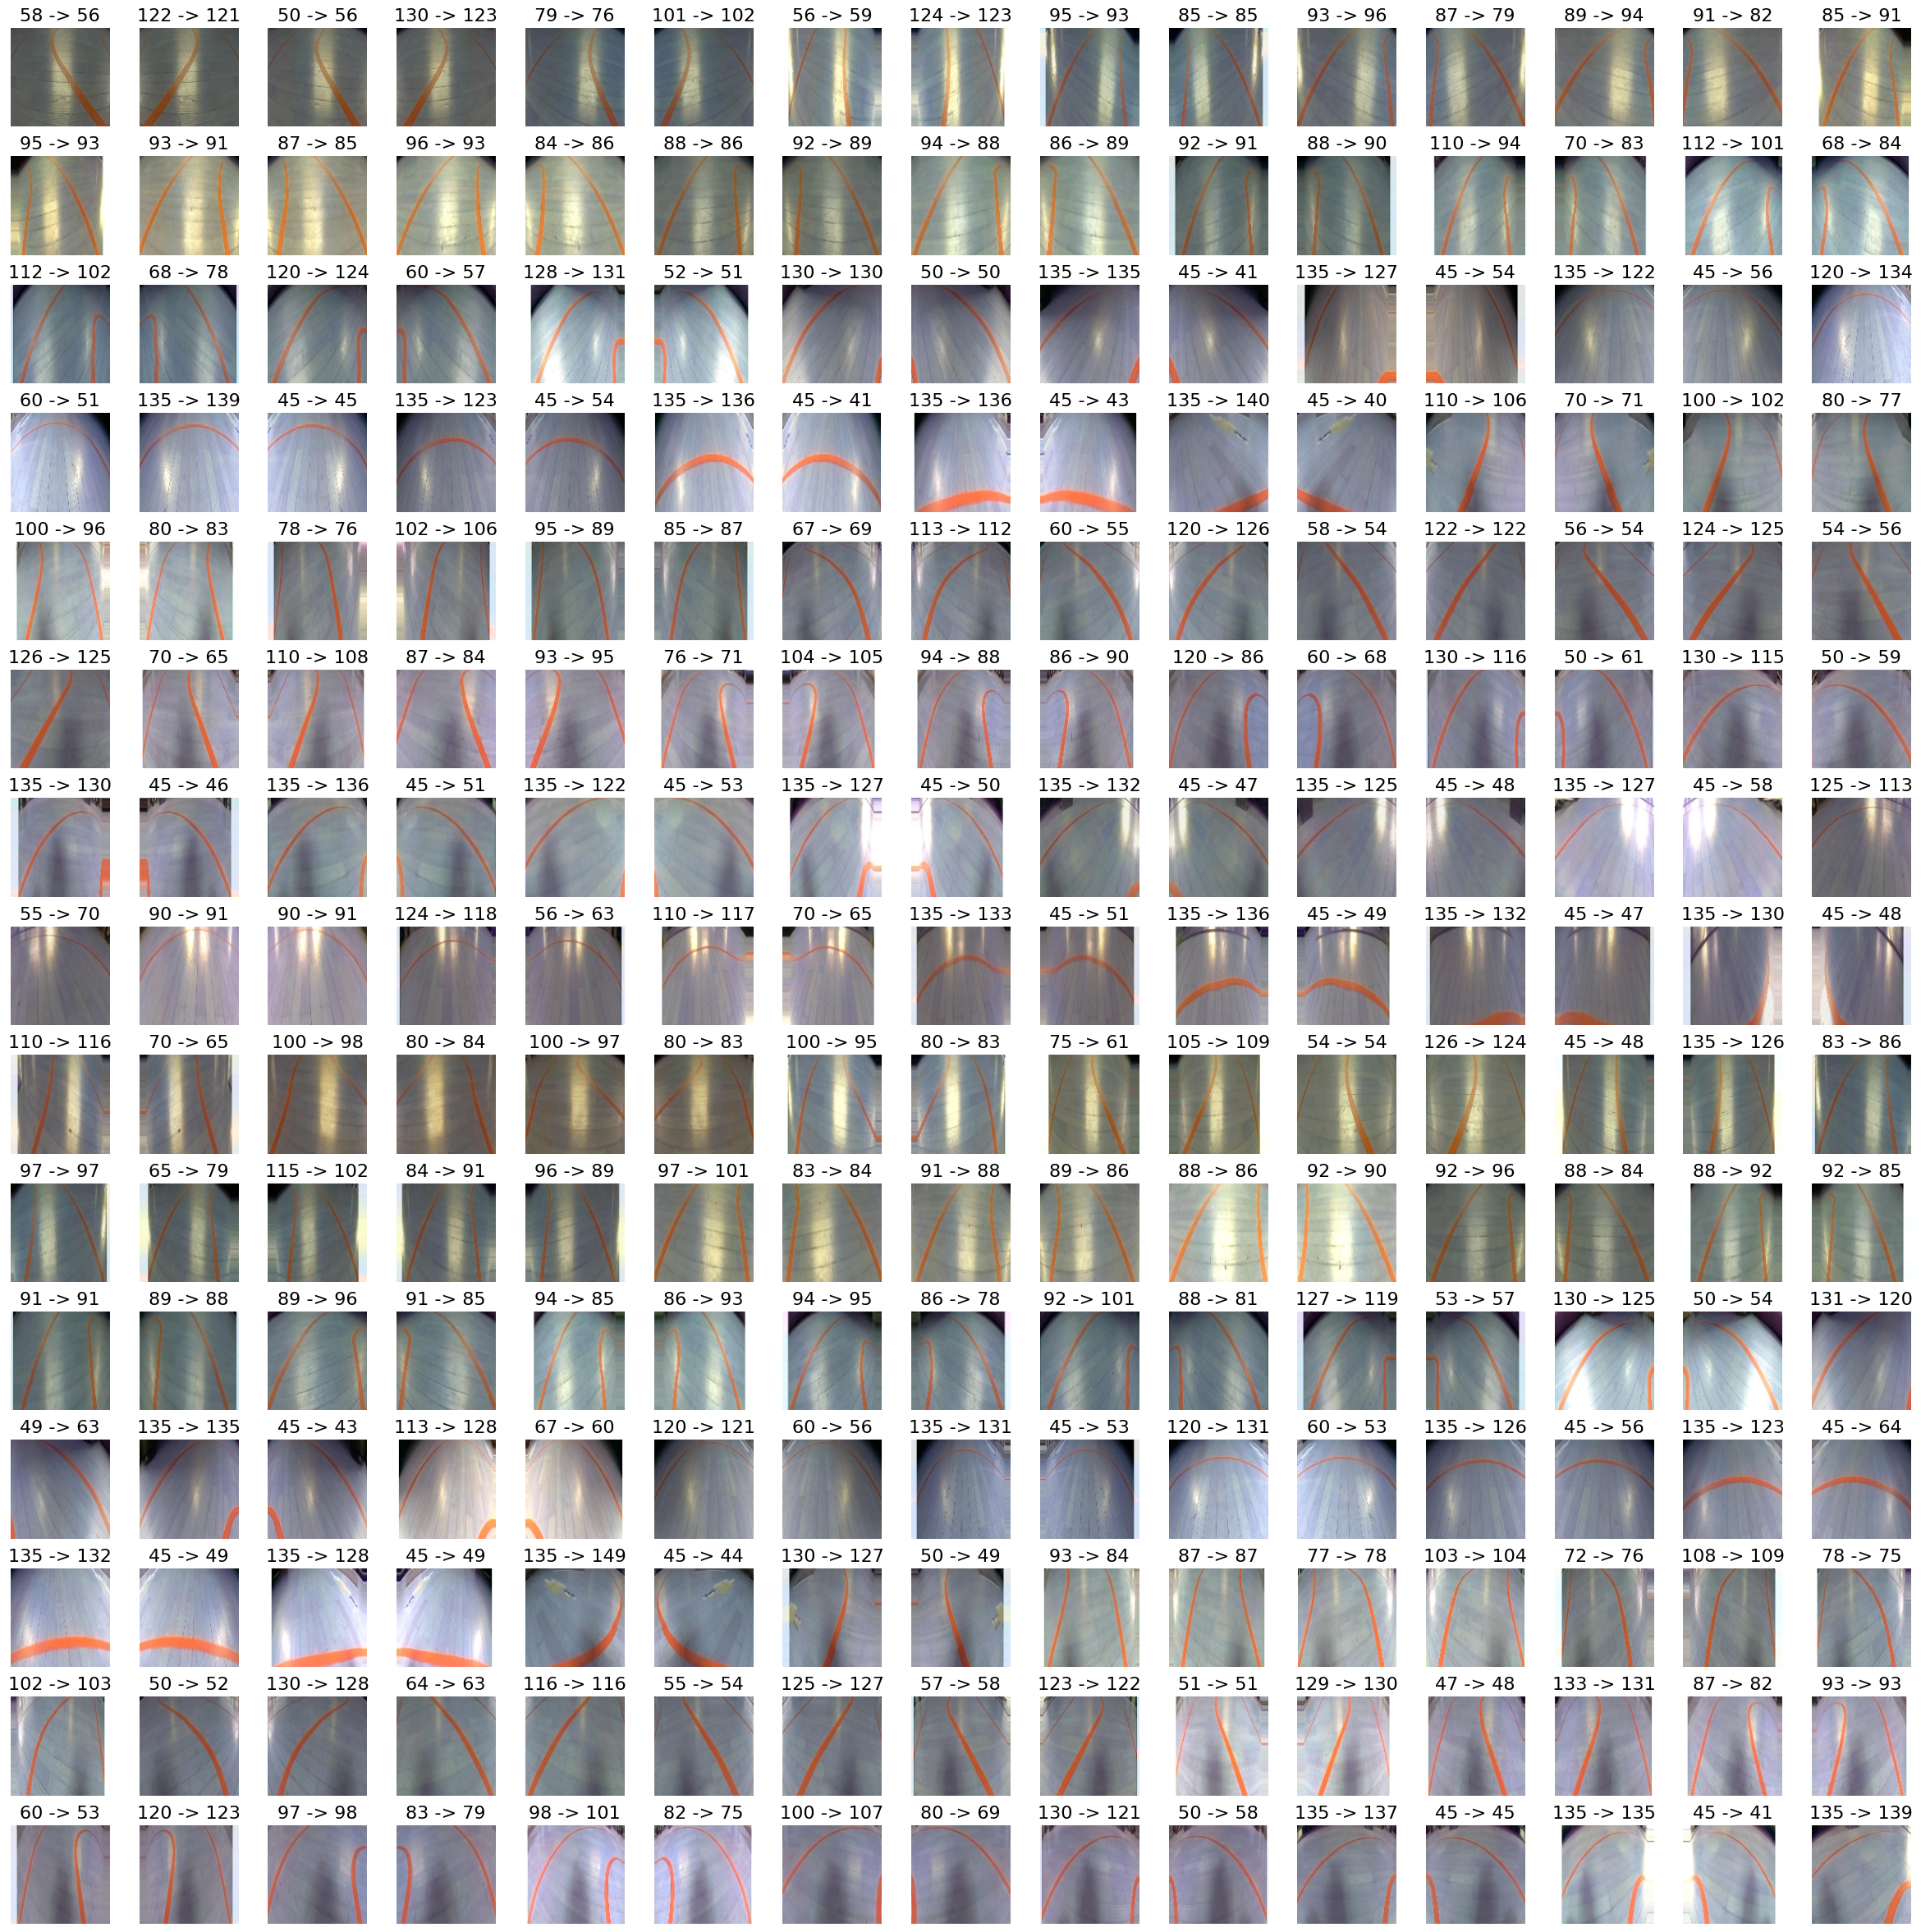

In [127]:
plot_images_from_array(images, labels, y_pred, grid=(15,15),figsize=(30,30))

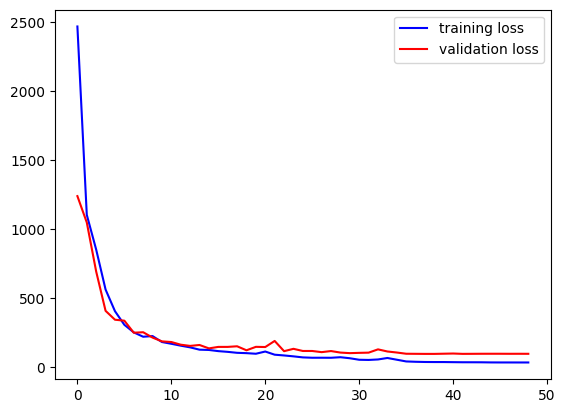

In [128]:
plot_train_history(history)

In [129]:
model_name = "powerful-frog-373"

In [130]:
model.save(model_name + '.keras') #.keras

In [131]:
loaded_model = tf.keras.models.load_model(model_name + '.keras')

In [132]:
y_pred = loaded_model.predict(images)

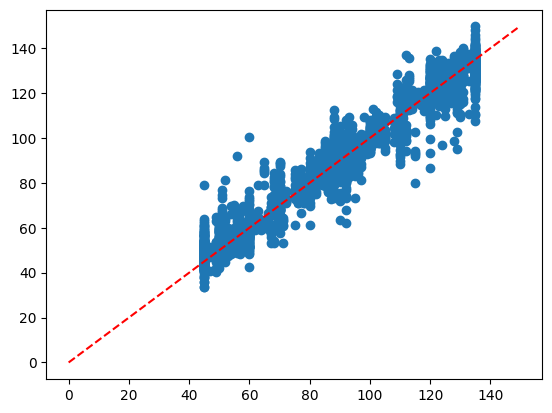

In [133]:
# idealerweise schwanken werte um die Winkelhalbierende
plt.scatter(labels, y_pred)
points = np.array([0, np.max(y_pred)])
plt.plot( points, points, 'r--', label='')

In [134]:
converter = tf.lite.TFLiteConverter.from_keras_model(loaded_model)

In [135]:
tflite_model = converter.convert()

INFO:tensorflow:Assets written to: C:\Users\VWN7QRY\AppData\Local\Temp\tmp5kd0yj0z\assets


In [137]:
with open(model_name + ".tflite", 'wb') as f:
    f.write(tflite_model)

In [64]:
np.__version__

'1.20.2'